## Block 1.1 — Load & Grayscale
Purpose: load a Sudoku photo and convert it to grayscale as the first step of grid extraction.
Roadmap phase: Phase 1
Files: image_processing/
Expected output: original image and grayscale image displayed side by side

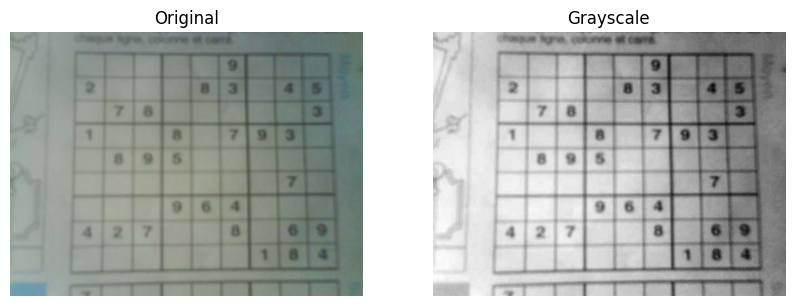

In [22]:
import cv2
import matplotlib.pyplot as plt

image_path = "sudoku_dataset/images/image32.jpg"
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")
plt.show()

## Block 1.2 — Noise Removal & Thresholding
Purpose: reduce noise and highlight the grid lines so contours can be detected in the next block.
Roadmap phase: Phase 1
Files: image_processing/
Related blocks: uses output of Block 1.1
Expected output: blurred image and thresholded (binary) image displayed

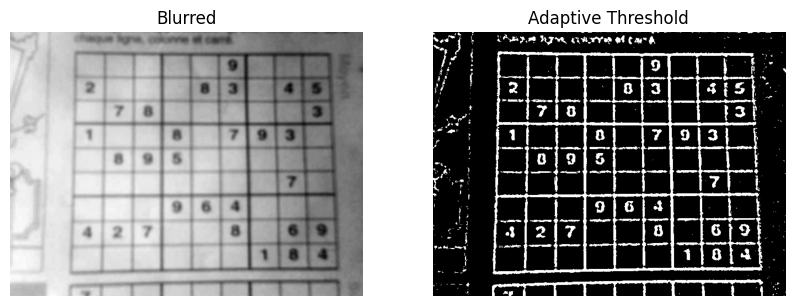

In [23]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

thresh = cv2.adaptiveThreshold(
    blurred, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(blurred, cmap="gray")
axes[0].set_title("Blurred")
axes[0].axis("off")
axes[1].imshow(thresh, cmap="gray")
axes[1].set_title("Adaptive Threshold")
axes[1].axis("off")
plt.show()

## Block 1.3 — Grid Contour Detection
Purpose: locate the Sudoku grid's outer border in the thresholded image and extract its 4 corners.
Roadmap phase: Phase 1
Files: image_processing/
Related blocks: uses output of Block 1.2
Expected output: original image with the detected grid border drawn on it

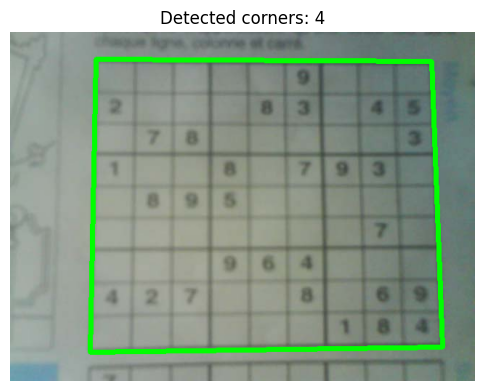

Corner points: [[118  37]
 [110 440]
 [595 433]
 [580  40]]


In [26]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest_contour = max(contours, key=cv2.contourArea)

perimeter = cv2.arcLength(largest_contour, True)
approx = cv2.approxPolyDP(largest_contour, 0.04 * perimeter, True)

display_image = image.copy()
cv2.drawContours(display_image, [approx], -1, (0, 255, 0), 5)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB))
plt.title(f"Detected corners: {len(approx)}")
plt.axis("off")
plt.show()

print("Corner points:", approx.reshape(-1, 2))

## Block 1.4 — Perspective Transform
Purpose: warp the detected grid to a flat top-down square view, and store the transform matrix for later use (Bonus #4 overlay in Phase 4).
Roadmap phase: Phase 1
Files: image_processing/
Related blocks: uses output of Block 1.3
Expected output: warped square grid image

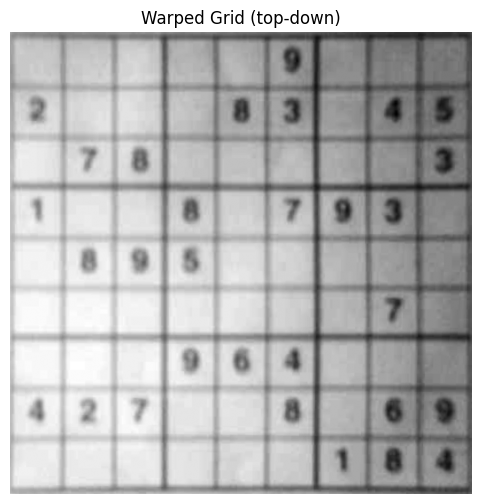

In [27]:
import numpy as np

def order_corners(pts):
    pts = pts.reshape(4, 2)
    ordered = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    ordered[0] = pts[np.argmin(s)]   # top-left: smallest x+y
    ordered[2] = pts[np.argmax(s)]   # bottom-right: largest x+y

    diff = np.diff(pts, axis=1)
    ordered[1] = pts[np.argmin(diff)]  # top-right: smallest y-x
    ordered[3] = pts[np.argmax(diff)]  # bottom-left: largest y-x

    return ordered

corners = order_corners(approx)

side = 900  # output size, divisible by 9
dst = np.array([
    [0, 0],
    [side - 1, 0],
    [side - 1, side - 1],
    [0, side - 1]
], dtype="float32")

transform_matrix = cv2.getPerspectiveTransform(corners, dst)
warped = cv2.warpPerspective(gray, transform_matrix, (side, side))
warped_thresh = cv2.warpPerspective(thresh, transform_matrix, (side, side))
plt.figure(figsize=(6, 6))
plt.imshow(warped, cmap="gray")
plt.title("Warped Grid (top-down)")
plt.axis("off")
plt.show()

## Block 1.5 — Cell Splitting
Purpose: divide the warped 900x900 grid into 81 equal cells (9x9).
Roadmap phase: Phase 1
Files: image_processing/
Related blocks: uses output of Block 1.4
Expected output: grid of 81 cell images displayed together

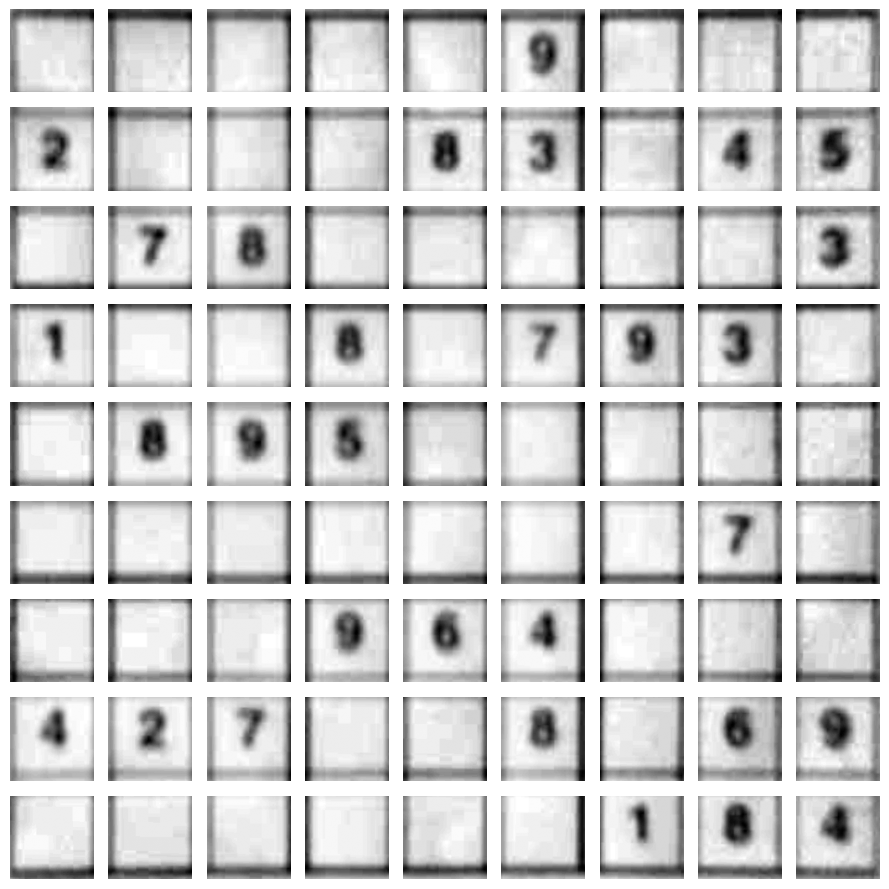

Total cells extracted: 81


In [28]:
cell_size = side // 9  # 900 // 9 = 100

cells = []
for row in range(9):
    for col in range(9):
        y1 = row * cell_size
        y2 = (row + 1) * cell_size
        x1 = col * cell_size
        x2 = (col + 1) * cell_size
        cell = warped[y1:y2, x1:x2]
        cells.append(cell)
cells_thresh = []
for row in range(9):
    for col in range(9):
        y1 = row * cell_size
        y2 = (row + 1) * cell_size
        x1 = col * cell_size
        x2 = (col + 1) * cell_size
        cells_thresh.append(warped_thresh[y1:y2, x1:x2])
fig, axes = plt.subplots(9, 9, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(cells[i], cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Total cells extracted:", len(cells))

## Block 1.6 — Clean Cells & Detect Empty Cells
Purpose: strip leftover grid-line fragments from cell edges and determine which cells are empty vs contain a digit.
Roadmap phase: Phase 1
Files: image_processing/
Related blocks: uses output of Block 1.5
Expected output: cleaned cells displayed, plus a 9x9 map of empty/non-empty flags

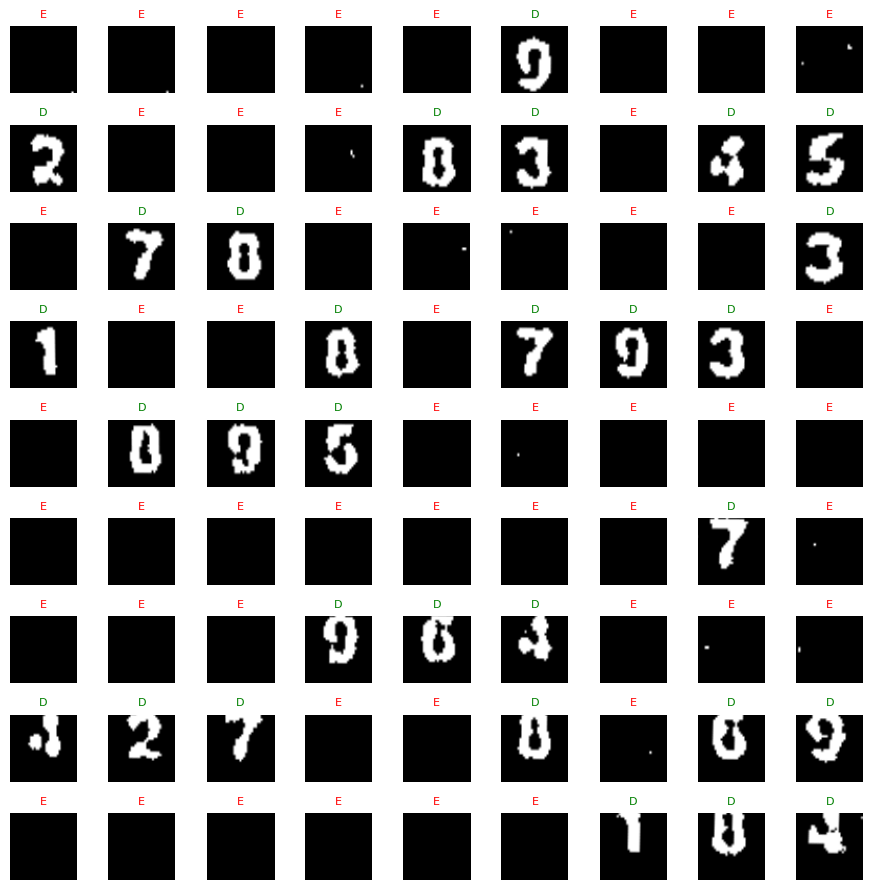

[[ True  True  True  True  True False  True  True  True]
 [False  True  True  True False False  True False False]
 [ True False False  True  True  True  True  True False]
 [False  True  True False  True False False False  True]
 [ True False False False  True  True  True  True  True]
 [ True  True  True  True  True  True  True False  True]
 [ True  True  True False False False  True  True  True]
 [False False False  True  True False  True False False]
 [ True  True  True  True  True  True False False False]]
Empty cells detected: 51


In [29]:
def clean_cell(cell, margin_ratio=0.18):
    h, w = cell.shape
    m = int(h * margin_ratio)
    return cell[m:h-m, m:w-m]

def is_empty(binary_cell, white_pixel_threshold=0.03):
    white_ratio = np.sum(binary_cell == 255) / binary_cell.size
    return white_ratio < white_pixel_threshold

cleaned_cells = []
empty_flags = []
for cell in cells_thresh:
    cleaned = clean_cell(cell)
    cleaned_cells.append(cleaned)
    empty_flags.append(is_empty(cleaned))
fig, axes = plt.subplots(9, 9, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(cleaned_cells[i], cmap="gray")
    ax.set_title("E" if empty_flags[i] else "D", fontsize=8, color="red" if empty_flags[i] else "green")
    ax.axis("off")
plt.tight_layout()
plt.show()
empty_grid = np.array(empty_flags).reshape(9, 9)
print(empty_grid)
print("Empty cells detected:", np.sum(empty_flags))

In [9]:
ratios = []
for cell in cleaned_cells:
    _, binary = cv2.threshold(cell, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    white_ratio = np.sum(binary == 255) / binary.size
    ratios.append(white_ratio)

ratios = np.array(ratios).reshape(9, 9)
np.set_printoptions(precision=3, suppress=True)
print(ratios)

[[0.089 0.084 0.829 0.819 0.069 0.817 0.152 0.084 0.114]
 [0.103 0.834 0.059 0.815 0.821 0.829 0.106 0.83  0.821]
 [0.833 0.103 0.112 0.829 0.818 0.161 0.104 0.837 0.817]
 [0.114 0.81  0.835 0.175 0.103 0.845 0.177 0.159 0.084]
 [0.087 0.841 0.162 0.113 0.161 0.085 0.151 0.153 0.051]
 [0.07  0.817 0.841 0.832 0.084 0.826 0.174 0.106 0.81 ]
 [0.176 0.85  0.104 0.157 0.848 0.113 0.158 0.829 0.845]
 [0.831 0.09  0.81  0.81  0.831 0.821 0.06  0.105 0.089]
 [0.106 0.085 0.848 0.823 0.092 0.826 0.115 0.84  0.07 ]]


In [11]:
sorted_ratios = np.sort(ratios.flatten())
for i, r in enumerate(sorted_ratios):
    print(i, round(r, 3))

0 0.051
1 0.059
2 0.06
3 0.069
4 0.07
5 0.07
6 0.084
7 0.084
8 0.084
9 0.084
10 0.085
11 0.085
12 0.087
13 0.089
14 0.089
15 0.09
16 0.092
17 0.103
18 0.103
19 0.103
20 0.104
21 0.104
22 0.105
23 0.106
24 0.106
25 0.106
26 0.112
27 0.113
28 0.113
29 0.114
30 0.114
31 0.115
32 0.151
33 0.152
34 0.153
35 0.157
36 0.158
37 0.159
38 0.161
39 0.161
40 0.162
41 0.174
42 0.175
43 0.176
44 0.177
45 0.81
46 0.81
47 0.81
48 0.81
49 0.815
50 0.817
51 0.817
52 0.817
53 0.818
54 0.819
55 0.821
56 0.821
57 0.821
58 0.823
59 0.826
60 0.826
61 0.829
62 0.829
63 0.829
64 0.829
65 0.83
66 0.831
67 0.831
68 0.832
69 0.833
70 0.834
71 0.835
72 0.837
73 0.84
74 0.841
75 0.841
76 0.845
77 0.845
78 0.848
79 0.848
80 0.85


In [12]:
print("Empty cells detected:", np.sum(empty_flags))
print("Digit cells detected:", 81 - np.sum(empty_flags))

Empty cells detected: 65
Digit cells detected: 16


In [13]:
ratios_grid = ratios.reshape(9, 9)
for r in range(9):
    row_str = " ".join(f"{ratios_grid[r][c]:.2f}" for c in range(9))
    print(f"row {r}: {row_str}")

row 0: 0.09 0.08 0.83 0.82 0.07 0.82 0.15 0.08 0.11
row 1: 0.10 0.83 0.06 0.82 0.82 0.83 0.11 0.83 0.82
row 2: 0.83 0.10 0.11 0.83 0.82 0.16 0.10 0.84 0.82
row 3: 0.11 0.81 0.84 0.18 0.10 0.84 0.18 0.16 0.08
row 4: 0.09 0.84 0.16 0.11 0.16 0.08 0.15 0.15 0.05
row 5: 0.07 0.82 0.84 0.83 0.08 0.83 0.17 0.11 0.81
row 6: 0.18 0.85 0.10 0.16 0.85 0.11 0.16 0.83 0.84
row 7: 0.83 0.09 0.81 0.81 0.83 0.82 0.06 0.11 0.09
row 8: 0.11 0.09 0.85 0.82 0.09 0.83 0.11 0.84 0.07


In [17]:
for r in range(9):
    row_str = " ".join("E" if empty_grid[r][c] else "D" for c in range(9))
    print(f"row {r}: {row_str}")

row 0: D D E E D E E D D
row 1: D E D E E E D E E
row 2: E D D E E E D E E
row 3: D E E E D E E E D
row 4: D E E D E D E E D
row 5: D E E E D E E D E
row 6: E E D E E D E E E
row 7: E D E E E E D D D
row 8: D D E E D E D E D


In [20]:
!git clone https://github.com/wichtounet/sudoku_dataset.git

Cloning into 'sudoku_dataset'...
remote: Enumerating objects: 1580, done.
remote: Total 1580 (delta 0), reused 0 (delta 0), pack-reused 1580 (from 1)
Receiving objects: 100% (1580/1580), 494.05 MiB | 49.98 MiB/s, done.
Resolving deltas: 100% (431/431), done.
Updating files: 100% (1021/1021), done.


In [21]:
!ls sudoku_dataset/images | head -20

image1000.dat
image1000.jpg
image1001.dat
image1001.jpg
image1003.dat
image1003.jpg
image1004.dat
image1004.jpg
image1005.dat
image1005.jpg
image1006.dat
image1006.jpg
image1007.dat
image1007.jpg
image1008.dat
image1008.jpg
image1009.dat
image1009.jpg
image100.dat
image100.jpg


## Block 1.7 — Save Phase 1 Checkpoint
Purpose: persist extracted cells, empty/digit flags, and transform matrices for the test set, so Phase 2 doesn't require re-running Phase 1 from scratch after a Colab restart.
Roadmap phase: Phase 1
Files: checkpoints/phase1/
Expected output: saved .npz file(s) confirmed on disk

In [30]:
import os

os.makedirs("checkpoints/phase1", exist_ok=True)

checkpoint_name = os.path.splitext(os.path.basename(image_path))[0]
save_path = f"checkpoints/phase1/{checkpoint_name}.npz"

np.savez(
    save_path,
    cells=np.array(cleaned_cells, dtype=object),
    empty_flags=np.array(empty_flags),
    transform_matrix=transform_matrix,
    corners=corners
)

print("Saved checkpoint to:", save_path)

Saved checkpoint to: checkpoints/phase1/image32.npz


In [31]:
!ls -la checkpoints/phase1/

total 660
drwxr-xr-x 2 root root   4096 Jul 11 20:00 .
drwxr-xr-x 3 root root   4096 Jul 11 20:00 ..
-rw-r--r-- 1 root root 665670 Jul 11 20:00 image32.npz


In [33]:
!git clone https://github.com/yektasharifpour/sudoku-cv-project.git


Cloning into 'sudoku-cv-project'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 14 (delta 3), reused 13 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), done.
Resolving deltas: 100% (3/3), done.


In [39]:
%cd sudoku-cv-project

/content/sudoku-cv-project


In [42]:
!git branch  phase1/feature/grid-extraction

In [43]:
!git checkout phase1/feature/grid-extraction

Switched to branch 'phase1/feature/grid-extraction'


In [44]:
!git branch --show-current

phase1/feature/grid-extraction


In [45]:
!git clone https://github.com/wichtounet/sudoku_dataset.git datasets/sudoku_dataset

Cloning into 'datasets/sudoku_dataset'...
remote: Enumerating objects: 1580, done.
remote: Total 1580 (delta 0), reused 0 (delta 0), pack-reused 1580 (from 1)
Receiving objects: 100% (1580/1580), 494.05 MiB | 52.30 MiB/s, done.
Resolving deltas: 100% (431/431), done.
Updating files: 100% (1021/1021), done.


In [46]:
!ls -la

total 64
drwxr-xr-x 12 root root 4096 Jul 11 20:09 .
drwxr-xr-x  1 root root 4096 Jul 11 20:09 ..
-rw-r--r--  1 root root 2034 Jul 11 20:09 branch-policy.md
drwxr-xr-x  2 root root 4096 Jul 11 20:09 checkpoints
drwxr-xr-x  3 root root 4096 Jul 11 20:15 datasets
drwxr-xr-x  2 root root 4096 Jul 11 20:09 digit_recognition
drwxr-xr-x  8 root root 4096 Jul 11 20:14 .git
-rw-r--r--  1 root root  457 Jul 11 20:09 .gitignore
drwxr-xr-x  2 root root 4096 Jul 11 20:09 image_processing
drwxr-xr-x  2 root root 4096 Jul 11 20:09 pipeline
-rw-r--r--  1 root root 2271 Jul 11 20:09 README.md
-rw-r--r--  1 root root  426 Jul 11 20:09 requirements.txt
drwxr-xr-x  2 root root 4096 Jul 11 20:09 solver
drwxr-xr-x  2 root root 4096 Jul 11 20:09 tests
drwxr-xr-x  2 root root 4096 Jul 11 20:09 ui
drwxr-xr-x  2 root root 4096 Jul 11 20:09 utils


In [47]:
!cat .gitignore

# Datasets (large, not committed as raw files)
datasets/*
!datasets/.gitkeep

# Checkpoints (intermediate artifacts — see README Checkpoint Policy)
checkpoints/*
!checkpoints/.gitkeep

# Model weights tracked via Git LFS instead of plain git blobs where large
# (see .gitattributes once added)

# Python
__pycache__/
*.pyc
*.pyo
.ipynb_checkpoints/
.env
.venv/
venv/

# Colab / Jupyter
*.ipynb_checkpoints

# OS
.DS_Store
Thumbs.db

# IDE
.vscode/
.idea/


In [48]:
with open(".gitignore", "r") as f:
    content = f.read()

content = content.replace(
    """# Datasets (large, not committed as raw files)
datasets/*
!datasets/.gitkeep

""", "")

content = content.replace(
    """# Checkpoints (intermediate artifacts — see README Checkpoint Policy)
checkpoints/*
!checkpoints/.gitkeep

""", "")

with open(".gitignore", "w") as f:
    f.write(content)

print(content)

# Model weights tracked via Git LFS instead of plain git blobs where large
# (see .gitattributes once added)

# Python
__pycache__/
*.pyc
*.pyo
.ipynb_checkpoints/
.env
.venv/
venv/

# Colab / Jupyter
*.ipynb_checkpoints

# OS
.DS_Store
Thumbs.db

# IDE
.vscode/
.idea/



In [49]:
!git clone https://github.com/wichtounet/sudoku_dataset.git datasets/sudoku_dataset

fatal: destination path 'datasets/sudoku_dataset' already exists and is not an empty directory.


In [50]:
!rm -rf datasets/sudoku_dataset/.git

In [51]:
!ls datasets/sudoku_dataset

baptiste.sh  jean.sh	       mixed_natural	    README.rst
datasets     mixed	       original		    tools
images	     mixed_incomplete  outlines_sorted.csv  wip


## Block 1.8 — Batch Testing Function
Purpose: wrap Blocks 1.1–1.7 into a single reusable function and run it across multiple test images in a loop.
Roadmap phase: Phase 1 (testing point)
Files: image_processing/
Expected output: pass/fail summary across the test image batch

In [52]:
def process_sudoku_image(image_path, epsilon_values=(0.02, 0.04, 0.05, 0.06)):
    image = cv2.imread(image_path)
    if image is None:
        return {"path": image_path, "status": "failed", "reason": "could not read image"}

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return {"path": image_path, "status": "failed", "reason": "no contours found"}
    largest_contour = max(contours, key=cv2.contourArea)
    perimeter = cv2.arcLength(largest_contour, True)

    approx = None
    for eps in epsilon_values:
        candidate = cv2.approxPolyDP(largest_contour, eps * perimeter, True)
        if len(candidate) == 4:
            approx = candidate
            break

    if approx is None:
        return {"path": image_path, "status": "failed", "reason": "could not find 4 corners"}

    corners = order_corners(approx)
    side = 900
    dst = np.array([[0,0],[side-1,0],[side-1,side-1],[0,side-1]], dtype="float32")
    transform_matrix = cv2.getPerspectiveTransform(corners, dst)
    warped = cv2.warpPerspective(gray, transform_matrix, (side, side))
    warped_thresh = cv2.warpPerspective(thresh, transform_matrix, (side, side))

    cell_size = side // 9
    cells_thresh = []
    for row in range(9):
        for col in range(9):
            y1, y2 = row*cell_size, (row+1)*cell_size
            x1, x2 = col*cell_size, (col+1)*cell_size
            cells_thresh.append(warped_thresh[y1:y2, x1:x2])

    def clean_cell(cell, margin_ratio=0.18):
        h, w = cell.shape
        m = int(h * margin_ratio)
        return cell[m:h-m, m:w-m]

    def is_empty(binary_cell, white_pixel_threshold=0.03):
        white_ratio = np.sum(binary_cell == 255) / binary_cell.size
        return white_ratio < white_pixel_threshold

    cleaned_cells = [clean_cell(c) for c in cells_thresh]
    empty_flags = [is_empty(c) for c in cleaned_cells]

    checkpoint_name = os.path.splitext(os.path.basename(image_path))[0]
    save_path = f"checkpoints/phase1/{checkpoint_name}.npz"
    os.makedirs("checkpoints/phase1", exist_ok=True)
    np.savez(save_path, cells=np.array(cleaned_cells, dtype=object),
             empty_flags=np.array(empty_flags), transform_matrix=transform_matrix, corners=corners)

    return {"path": image_path, "status": "passed", "checkpoint": save_path, "empty_count": int(np.sum(empty_flags))}

In [53]:
import glob

test_images = glob.glob("datasets/sudoku_dataset/images/*.jpg")[:20]

results = [process_sudoku_image(p) for p in test_images]

passed = [r for r in results if r["status"] == "passed"]
failed = [r for r in results if r["status"] == "failed"]

print(f"Passed: {len(passed)} / {len(results)}")
print(f"Failed: {len(failed)}")
for r in failed:
    print(" -", r["path"], "→", r["reason"])

Passed: 17 / 20
Failed: 3
 - datasets/sudoku_dataset/images/image76.jpg → could not find 4 corners
 - datasets/sudoku_dataset/images/image74.jpg → could not find 4 corners
 - datasets/sudoku_dataset/images/image196.jpg → could not find 4 corners


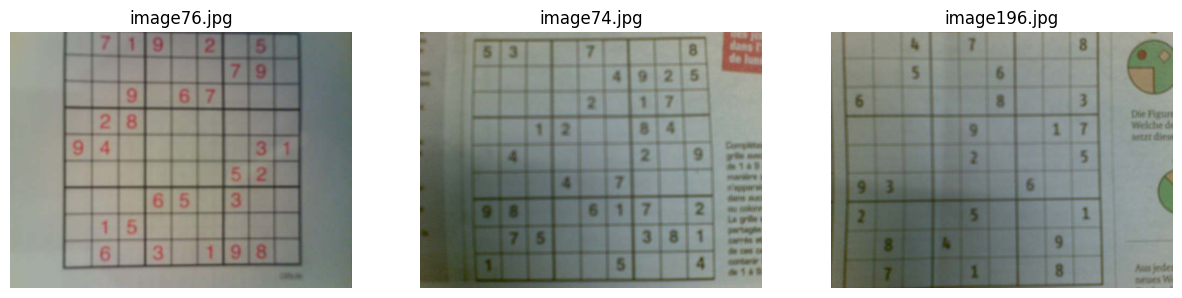

In [54]:
failed_paths = ["datasets/sudoku_dataset/images/image76.jpg",
                "datasets/sudoku_dataset/images/image74.jpg",
                "datasets/sudoku_dataset/images/image196.jpg"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, path in zip(axes, failed_paths):
    img = cv2.imread(path)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(path))
    ax.axis("off")
plt.show()

In [57]:
!git add .
!git commit -m "feat: Phase 1 grid extraction complete, add sudoku_dataset, checkpoints (17/20 test images passing)"

[phase1/feature/grid-extraction 4cdf913] feat: Phase 1 grid extraction complete, add sudoku_dataset, checkpoints (17/20 test images passing)
 1039 files changed, 5716 insertions(+), 8 deletions(-)
 create mode 100644 checkpoints/phase1/image100.npz
 create mode 100644 checkpoints/phase1/image1019.npz
 create mode 100644 checkpoints/phase1/image1050.npz
 create mode 100644 checkpoints/phase1/image111.npz
 create mode 100644 checkpoints/phase1/image113.npz
 create mode 100644 checkpoints/phase1/image125.npz
 create mode 100644 checkpoints/phase1/image127.npz
 create mode 100644 checkpoints/phase1/image154.npz
 create mode 100644 checkpoints/phase1/image161.npz
 create mode 100644 checkpoints/phase1/image164.npz
 create mode 100644 checkpoints/phase1/image165.npz
 create mode 100644 checkpoints/phase1/image194.npz
 create mode 100644 checkpoints/phase1/image26.npz
 create mode 100644 checkpoints/phase1/image35.npz
 create mode 100644 checkpoints/phase1/image56.npz
 create mode 100644 chec

In [56]:
!git config user.email "yekta1382.sharifpour@gmail.com"
!git config user.name "yektasharifpour"

In [58]:
!ls -la

total 64
drwxr-xr-x 12 root root 4096 Jul 11 20:09 .
drwxr-xr-x  1 root root 4096 Jul 11 20:09 ..
-rw-r--r--  1 root root 2034 Jul 11 20:09 branch-policy.md
drwxr-xr-x  3 root root 4096 Jul 11 20:21 checkpoints
drwxr-xr-x  3 root root 4096 Jul 11 20:15 datasets
drwxr-xr-x  2 root root 4096 Jul 11 20:09 digit_recognition
drwxr-xr-x  8 root root 4096 Jul 11 20:35 .git
-rw-r--r--  1 root root  270 Jul 11 20:17 .gitignore
drwxr-xr-x  2 root root 4096 Jul 11 20:09 image_processing
drwxr-xr-x  2 root root 4096 Jul 11 20:09 pipeline
-rw-r--r--  1 root root 2271 Jul 11 20:09 README.md
-rw-r--r--  1 root root  426 Jul 11 20:09 requirements.txt
drwxr-xr-x  2 root root 4096 Jul 11 20:09 solver
drwxr-xr-x  2 root root 4096 Jul 11 20:09 tests
drwxr-xr-x  2 root root 4096 Jul 11 20:09 ui
drwxr-xr-x  2 root root 4096 Jul 11 20:09 utils


In [59]:
!pwd
!ls -la notebooks/

/content/sudoku-cv-project
ls: cannot access 'notebooks/': No such file or directory


In [60]:
!mkdir -p notebooks
!ls -la

total 68
drwxr-xr-x 13 root root 4096 Jul 11 20:39 .
drwxr-xr-x  1 root root 4096 Jul 11 20:09 ..
-rw-r--r--  1 root root 2034 Jul 11 20:09 branch-policy.md
drwxr-xr-x  3 root root 4096 Jul 11 20:21 checkpoints
drwxr-xr-x  3 root root 4096 Jul 11 20:15 datasets
drwxr-xr-x  2 root root 4096 Jul 11 20:09 digit_recognition
drwxr-xr-x  8 root root 4096 Jul 11 20:35 .git
-rw-r--r--  1 root root  270 Jul 11 20:17 .gitignore
drwxr-xr-x  2 root root 4096 Jul 11 20:09 image_processing
drwxr-xr-x  2 root root 4096 Jul 11 20:39 notebooks
drwxr-xr-x  2 root root 4096 Jul 11 20:09 pipeline
-rw-r--r--  1 root root 2271 Jul 11 20:09 README.md
-rw-r--r--  1 root root  426 Jul 11 20:09 requirements.txt
drwxr-xr-x  2 root root 4096 Jul 11 20:09 solver
drwxr-xr-x  2 root root 4096 Jul 11 20:09 tests
drwxr-xr-x  2 root root 4096 Jul 11 20:09 ui
drwxr-xr-x  2 root root 4096 Jul 11 20:09 utils


In [61]:
from google.colab import files
uploaded = files.upload()

Saving phase1_grid_extraction.ipynb to phase1_grid_extraction.ipynb


In [62]:
import shutil
shutil.move("phase1_grid_extraction.ipynb", "notebooks/phase1_grid_extraction.ipynb")
!ls -la notebooks/

total 1740
drwxr-xr-x  2 root root    4096 Jul 11 20:40 .
drwxr-xr-x 13 root root    4096 Jul 11 20:40 ..
-rw-r--r--  1 root root 1770355 Jul 11 20:40 phase1_grid_extraction.ipynb


In [63]:
!git add notebooks/phase1_grid_extraction.ipynb
!git commit -m "docs: add Phase 1 notebook"
!git push

[phase1/feature/grid-extraction 336a1f1] docs: add Phase 1 notebook
 1 file changed, 2398 insertions(+)
 create mode 100644 notebooks/phase1_grid_extraction.ipynb
fatal: The current branch phase1/feature/grid-extraction has no upstream branch.
To push the current branch and set the remote as upstream, use

    git push --set-upstream origin phase1/feature/grid-extraction



In [ ]:
!git push --set-upstream origin phase1/feature/grid-extraction

Enumerating objects: 836, done.
Counting objects: 100% (835/835), done.
Delta compression using up to 2 threads
Compressing objects: 100% (822/822), done.
